In [ ]:
!ls /content

sample_data			training.1600000.processed.noemoticon.csv.zip
train-balanced-sarcasm.csv.zip


In [14]:
import zipfile
import os

# نعمل فولدر للداتا
os.makedirs("/content/data", exist_ok=True)

# نفك ضغط ملف Sentiment
with zipfile.ZipFile("/content/training.1600000.processed.noemoticon.csv.zip", "r") as z:
    z.extractall("/content/data")

# نفك ضغط ملف Sarcasm
with zipfile.ZipFile("/content/train-balanced-sarcasm.csv.zip", "r") as z:
    z.extractall("/content/data")


In [ ]:
!ls /content/data


train-balanced-sarcasm.csv  training.1600000.processed.noemoticon.csv


In [12]:
import pandas as pd

sentiment_cols = ["target", "id", "date", "query", "user", "text"]

sentiment_df = pd.read_csv(
    "/content/data/training.1600000.processed.noemoticon.csv",
    encoding="latin-1",
    names=sentiment_cols
)

sentiment_df.head()


,target,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [16]:
sarcasm_df = pd.read_csv("/content/data/train-balanced-sarcasm.csv")

print("Sarcasm shape:", sarcasm_df.shape)
print("Sarcasm columns:", sarcasm_df.columns)

sarcasm_df.head()


Sarcasm shape: (1010826, 10)
Sarcasm columns: Index(['label', 'comment', 'author', 'subreddit', 'score', 'ups', 'downs',
       'date', 'created_utc', 'parent_comment'],
      dtype='object')


,label,comment,author,subreddit,score,ups,downs,date,created_utc,parent_comment
0,0,NC and NH.,Trumpbart,politics,2,-1,-1,2016-10,2016-10-16 23:55:23,"Yeah, I get that argument. At this point, I'd ..."
1,0,You do know west teams play against west teams...,Shbshb906,nba,-4,-1,-1,2016-11,2016-11-01 00:24:10,The blazers and Mavericks (The wests 5 and 6 s...
2,0,"They were underdogs earlier today, but since G...",Creepeth,nfl,3,3,0,2016-09,2016-09-22 21:45:37,They're favored to win.
3,0,"This meme isn't funny none of the ""new york ni...",icebrotha,BlackPeopleTwitter,-8,-1,-1,2016-10,2016-10-18 21:03:47,deadass don't kill my buzz
4,0,I could use one of those tools.,cush2push,MaddenUltimateTeam,6,-1,-1,2016-12,2016-12-30 17:00:13,Yep can confirm I saw the tool they use for th...


In [19]:
# هذا الكود فقط لتثبيت أسماء الداتا (تصحيح لخبطة)
# لا تدريب ولا preprocessing هنا

import pandas as pd

# ===== Sentiment =====
sentiment_cols = ["target", "id", "date", "query", "user", "text"]
sentiment_raw = pd.read_csv(
    "/content/data/training.1600000.processed.noemoticon.csv",
    encoding="latin-1",
    names=sentiment_cols
)

sentiment_raw = sentiment_raw[sentiment_raw["target"].isin([0,4])]
sentiment_raw["sentiment"] = sentiment_raw["target"].map({0:"negative", 4:"positive"})

sentiment_clean = sentiment_raw[["text", "sentiment"]]

# ===== Sarcasm =====
sarcasm_raw = pd.read_csv("/content/data/train-balanced-sarcasm.csv")
sarcasm_clean = sarcasm_raw[["comment", "label"]].rename(columns={"comment":"text"})

print("sentiment_clean columns:", sentiment_clean.columns)
print("sarcasm_clean columns:", sarcasm_clean.columns)


sentiment_clean columns: Index(['text', 'sentiment'], dtype='object')
sarcasm_clean columns: Index(['text', 'label'], dtype='object')


In [20]:
sentiment_sample = sentiment_clean.sample(100000, random_state=42)
sarcasm_sample = sarcasm_clean.sample(100000, random_state=42)

print(sentiment_sample["sentiment"].value_counts())
print(sarcasm_sample["label"].value_counts())


sentiment
positive    50057
negative    49943
Name: count, dtype: int64
label
1    50120
0    49880
Name: count, dtype: int64


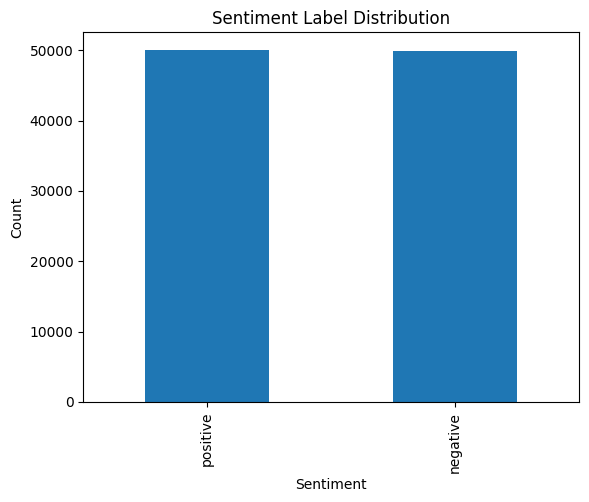

In [32]:
import matplotlib.pyplot as plt

sentiment_sample["sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Label Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


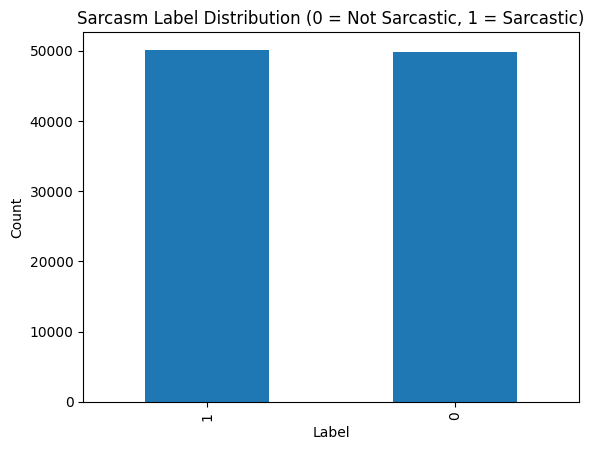

In [33]:
sarcasm_sample["label"].value_counts().plot(kind="bar")
plt.title("Sarcasm Label Distribution (0 = Not Sarcastic, 1 = Sarcastic)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


In [21]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)   # remove URLs
    text = re.sub(r"@\w+", "", text)             # remove mentions
    text = re.sub(r"[^a-z\s]", " ", text)        # keep letters only
    text = re.sub(r"\s+", " ", text).strip()     # remove extra spaces
    return text

sentiment_sample["clean_text"] = sentiment_sample["text"].apply(clean_text)
sarcasm_sample["clean_text"]   = sarcasm_sample["text"].apply(clean_text)

sentiment_sample[["text","clean_text","sentiment"]].head()


,text,clean_text,sentiment
541200,@chrishasboobs AHHH I HOPE YOUR OK!!!,ahhh i hope your ok,negative
750,"@misstoriblack cool , i have no tweet apps fo...",cool i have no tweet apps for my razr,negative
766711,@TiannaChaos i know just family drama. its la...,i know just family drama its lame hey next tim...,negative
285055,School email won't open and I have geography ...,school email won t open and i have geography s...,negative
705995,upper airways problem,upper airways problem,negative


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer


X = sentiment_sample["clean_text"]
y = sentiment_sample["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


tfidf_sent = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2)
)


X_train_vec = tfidf_sent.fit_transform(X_train)
X_test_vec  = tfidf_sent.transform(X_test)


In [23]:
print(X_train_vec.shape)
print(X_test_vec.shape)


(80000, 50000)
(20000, 50000)


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sent_lr = LogisticRegression(max_iter=200)
sent_lr.fit(X_train_vec, y_train)

y_pred = sent_lr.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.794

Confusion Matrix:
 [[7856 2133]
 [1987 8024]]

Classification Report:
               precision    recall  f1-score   support

    negative       0.80      0.79      0.79      9989
    positive       0.79      0.80      0.80     10011

    accuracy                           0.79     20000
   macro avg       0.79      0.79      0.79     20000
weighted avg       0.79      0.79      0.79     20000



In [25]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sent_svm = LinearSVC()
sent_svm.fit(X_train_vec, y_train)

y_pred_svm = sent_svm.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))


Accuracy: 0.7808

Confusion Matrix:
 [[7692 2297]
 [2087 7924]]

Classification Report:
               precision    recall  f1-score   support

    negative       0.79      0.77      0.78      9989
    positive       0.78      0.79      0.78     10011

    accuracy                           0.78     20000
   macro avg       0.78      0.78      0.78     20000
weighted avg       0.78      0.78      0.78     20000



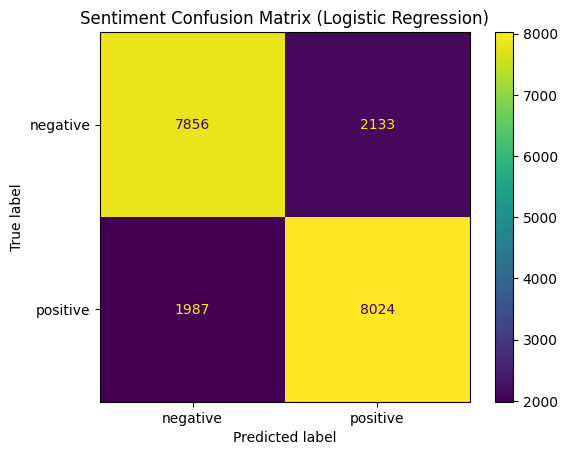

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["negative", "positive"],
    values_format="d"
)

plt.title("Sentiment Confusion Matrix (Logistic Regression)")
plt.show()


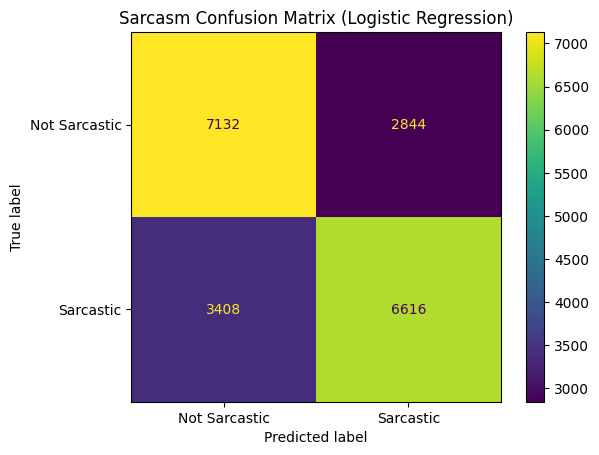

In [35]:
ConfusionMatrixDisplay.from_predictions(
    y_sarc_test,
    y_pred_sarc_lr,
    display_labels=["Not Sarcastic", "Sarcastic"],
    values_format="d"
)

plt.title("Sarcasm Confusion Matrix (Logistic Regression)")
plt.show()


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X_sarc = sarcasm_sample["clean_text"]
y_sarc = sarcasm_sample["label"]

X_sarc_train, X_sarc_test, y_sarc_train, y_sarc_test = train_test_split(
    X_sarc, y_sarc,
    test_size=0.2,
    random_state=42,
    stratify=y_sarc
)

tfidf_sarc = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2)
)

X_sarc_train_vec = tfidf_sarc.fit_transform(X_sarc_train)
X_sarc_test_vec  = tfidf_sarc.transform(X_sarc_test)

print(X_sarc_train_vec.shape)
print(X_sarc_test_vec.shape)


(80000, 50000)
(20000, 50000)


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sarc_lr = LogisticRegression(max_iter=200)
sarc_lr.fit(X_sarc_train_vec, y_sarc_train)

y_pred_sarc_lr = sarc_lr.predict(X_sarc_test_vec)

print("Accuracy:", accuracy_score(y_sarc_test, y_pred_sarc_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_sarc_test, y_pred_sarc_lr))
print("\nClassification Report:\n", classification_report(y_sarc_test, y_pred_sarc_lr))


Accuracy: 0.6874

Confusion Matrix:
 [[7132 2844]
 [3408 6616]]

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.71      0.70      9976
           1       0.70      0.66      0.68     10024

    accuracy                           0.69     20000
   macro avg       0.69      0.69      0.69     20000
weighted avg       0.69      0.69      0.69     20000



In [29]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sarc_svm = LinearSVC()
sarc_svm.fit(X_sarc_train_vec, y_sarc_train)

y_pred_sarc_svm = sarc_svm.predict(X_sarc_test_vec)

print("Accuracy:", accuracy_score(y_sarc_test, y_pred_sarc_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_sarc_test, y_pred_sarc_svm))
print("\nClassification Report:\n", classification_report(y_sarc_test, y_pred_sarc_svm))


Accuracy: 0.66605

Confusion Matrix:
 [[6748 3228]
 [3451 6573]]

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.68      0.67      9976
           1       0.67      0.66      0.66     10024

    accuracy                           0.67     20000
   macro avg       0.67      0.67      0.67     20000
weighted avg       0.67      0.67      0.67     20000



In [30]:
def predict_sentiment_with_sarcasm(text):
    # 1) تنظيف النص
    clean = clean_text(text)

    # 2) Sentiment prediction
    sent_vec = tfidf_sent.transform([clean])
    sent_pred = sent_lr.predict(sent_vec)[0]

    # 3) Sarcasm prediction
    sarc_vec = tfidf_sarc.transform([clean])
    sarc_pred = sarc_lr.predict(sarc_vec)[0]

    # 4) تعديل المشاعر إذا النص ساخر
    if sarc_pred == 1:
        adjusted_sentiment = "negative" if sent_pred == "positive" else "positive"
    else:
        adjusted_sentiment = sent_pred

    return {
        "text": text,
        "sentiment": sent_pred,
        "sarcasm": sarc_pred,
        "adjusted_sentiment": adjusted_sentiment
    }


In [31]:
examples = [
    "I just love waiting in traffic for hours",
    "This phone is amazing and works perfectly",
    "Oh great, another exam tomorrow",
    "I am very happy with the service",
    "Yeah right, this is the best day ever"
]

results = [predict_sentiment_with_sarcasm(t) for t in examples]

import pandas as pd
pd.DataFrame(results)


,text,sentiment,sarcasm,adjusted_sentiment
0,I just love waiting in traffic for hours,positive,1,negative
1,This phone is amazing and works perfectly,positive,0,positive
2,"Oh great, another exam tomorrow",negative,1,positive
3,I am very happy with the service,positive,0,positive
4,"Yeah right, this is the best day ever",positive,1,negative
